In [1]:
# Importing the naccessry tools 
import pandas as pd 
import numpy as np
import plotly.express as px

# importing the ML tools 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
# Imporitng the advanced metrics tools 
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

print("Tools imported !!")

Tools imported !!


In [2]:
# 1. Simulate a dataset of 400 Students
rng = np.random.default_rng(seed=7)
study_hours  = rng.uniform(1, 10, size=400)
sleep_hours  = rng.uniform(4, 9, size=400)
distractions = rng.uniform(0, 5, size=400)

# Score formula, anyone above 70 Passes (1), otherwise Fails (0)
hidden_scores = 40 + (6.5 * study_hours) + (1.2 * sleep_hours) - (2.0 * distractions) + rng.normal(0, 7, size=400)
y = (hidden_scores >= 70).astype(int)
X = pd.DataFrame({'Study_Hours': study_hours, 'Sleep_Hours': sleep_hours, 'Distractions': distractions})

# Let's view our simulated students!
df_students = X.copy()
df_students['Pass_Fail'] = y
print("--- SIMULATED STUDENT DATA ---")
display(df_students.head())

# 2. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
print("\nData Split! Ready for training.")

--- SIMULATED STUDENT DATA ---


,Study_Hours,Sleep_Hours,Distractions,Pass_Fail
0,6.625859,5.647171,4.986138,1
1,9.074924,8.683216,0.783345,1
2,7.981171,4.775651,4.064277,1
3,3.026865,6.572332,2.055465,0
4,3.701497,4.457770,3.916538,0



Data Split! Ready for training.


In [17]:
model=DecisionTreeClassifier(max_depth=3,random_state=42)
model.fit(X_train,y_train)

print("Training Score : ",model.score(X_train,y_train)*100,"%")
print("Testing score : ",model.score(X_test,y_test)*100,"%")

Training Score :  95.3125 %
Testing score :  93.75 %


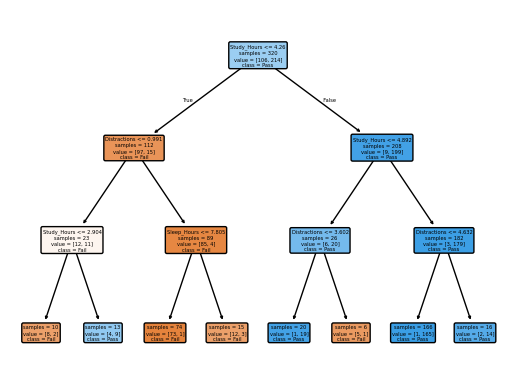

In [23]:
fig=plot_tree(model,
          feature_names=X.columns,
          class_names=['Fail', 'Pass'],
          filled=True,
          rounded=True,
          impurity=False,       # This hides the confusing Gini/Entropy math
          proportion=False)  


In [25]:
rf_model=RandomForestClassifier(n_estimators=100,max_depth=3,random_state=42)
rf_model.fit(X_train,y_train)

print("The training accuracy of model : ",rf_model.score(X_train,y_train)*100,"%")
print("The testing accuracy of model : ",rf_model.score(X_test,y_test)*100,"%")

The training accuracy of model :  95.0 %
The testing accuracy of model :  97.5 %


In [32]:
feature_importance=pd.DataFrame({
    "Feature":X.columns,
    "Feature_Value":rf_model.feature_importances_*100

}).sort_values(by="Feature_Value",ascending=False)

fig=px.bar(
    feature_importance,
    x="Feature",
    y="Feature_Value",
    title="features importance"

)
fig.show()

Decision Tree — Feature Importances:
(Higher = this feature was used more often, for more impactful splits)
  study_hours    :  0.829  ████████████████████████
  sleep_hours    :  0.021  
  distractions   :   0.15  ████

Predictions on 8 Test Students:
#     Study  Sleep  Dist   Actual     Pred   P(Pass)
-------------------------------------------------------
1       1.7    5.1   2.1     Fail     Fail      0.00
2       3.2    5.9   0.0     Fail     Pass      0.82
3       1.1    5.9   2.0     Fail     Fail      0.00
4       4.1    6.1   4.7     Fail     Fail      0.00
5       5.5    8.7   2.4     Pass     Pass      0.97
6       5.2    6.3   1.2     Pass     Pass      0.97
7       5.8    6.3   2.7     Pass     Pass      0.97
8       9.2    7.9   4.1     Pass     Pass      1.00

Decision Tree Accuracy: 92.5%
Random Forest — Feature Importances (averaged across 100 trees):
  study_hours    :  0.751  ██████████████████████
  sleep_hours    :  0.112  ███
  distractions   :  0.136  ████

Accu

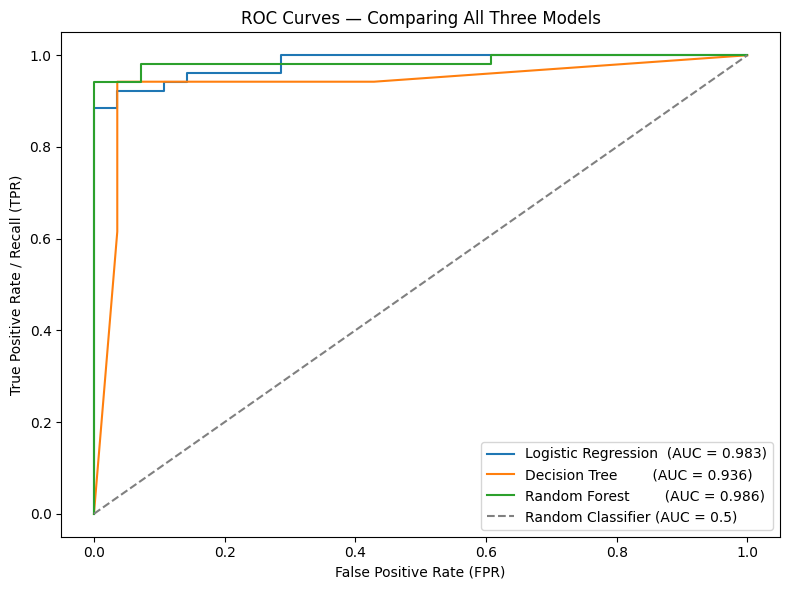


Full Metric Summary:
Model                           Accuracy  Precision   Recall       F1      AUC
------------------------------------------------------------------------------
Logistic Regression                0.925       0.96    0.923    0.941    0.983
Decision Tree (depth=4)            0.925      0.942    0.942    0.942    0.936
Random Forest (100 trees)           0.95      0.962    0.962    0.962    0.986


In [35]:
# Import numpy for data creation and numerical operations
import numpy as np

# Import DecisionTreeClassifier — the rule-based classification model
from sklearn.tree import DecisionTreeClassifier

# Import train_test_split to separate training and test data
from sklearn.model_selection import train_test_split

# Import accuracy_score to measure overall prediction correctness
from sklearn.metrics import accuracy_score

# Set seed for reproducibility
rng = np.random.default_rng(seed=7)

# Create 400 students with 3 features
n = 400
study_hours  = rng.uniform(1, 10, size=n)    # daily study hours (1 to 10)
sleep_hours  = rng.uniform(4, 9, size=n)     # daily sleep hours (4 to 9)
distractions = rng.uniform(0, 5, size=n)     # daily distraction hours (0 to 5)

# Simulate exam scores using the same formula as last session
scores = (
    40
    + 6.5 * study_hours         # study hours have the biggest positive effect
    + 1.2 * sleep_hours         # sleep has a moderate positive effect
    - 2.0 * distractions        # distractions reduce the score
    + rng.normal(0, 7, size=n)  # random noise for realism
)

# Create binary target: 1 = Pass (score >= 70), 0 = Fail
y = (scores >= 70).astype(int)

# Stack features into a 2D table (400 rows x 3 columns)
X = np.column_stack([study_hours, sleep_hours, distractions])

# Name the features — used for labelling outputs
feature_names = ["study_hours", "sleep_hours", "distractions"]

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

# Create a Decision Tree with maximum depth of 4
# max_depth=4 means the tree can ask at most 4 questions in sequence
# Without this limit, the tree would overfit by memorising every training student
tree = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train the tree — it learns the best set of if-else rules from the training data
tree.fit(X_train, y_train)

# Predict class labels for test students
y_pred_tree = tree.predict(X_test)

# Predict probabilities for test students
y_prob_tree = tree.predict_proba(X_test)

# --- Display Feature Importances ---
# Feature importance tells us which features the tree relied on most for its splits
print("Decision Tree — Feature Importances:")
print("(Higher = this feature was used more often, for more impactful splits)")
for name, importance in zip(feature_names, tree.feature_importances_):
    bar = "█" * int(importance * 30)
    print(f"  {name:<15}: {round(importance, 3):>6}  {bar}")

# --- Show predictions for the first 8 test students ---
print("\nPredictions on 8 Test Students:")
print(f"{'#':<4} {'Study':>6} {'Sleep':>6} {'Dist':>5} {'Actual':>8} {'Pred':>8} {'P(Pass)':>9}")
print("-" * 55)
for i in range(8):
    study  = X_test[i][0]
    sleep  = X_test[i][1]
    dist   = X_test[i][2]
    actual = "Pass" if y_test[i] == 1 else "Fail"
    pred   = "Pass" if y_pred_tree[i] == 1 else "Fail"
    p_pass = y_prob_tree[i][1]
    print(f"{i+1:<4} {study:>6.1f} {sleep:>6.1f} {dist:>5.1f} {actual:>8} {pred:>8} {p_pass:>9.2f}")

# --- Print overall accuracy ---
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"\nDecision Tree Accuracy: {round(acc_tree * 100, 1)}%")

# Import RandomForestClassifier — the ensemble of many Decision Trees
from sklearn.ensemble import RandomForestClassifier

# Import accuracy_score (already imported above, included here for clarity)
from sklearn.metrics import accuracy_score

# (All data and train/test split from the Decision Tree section above are reused here)

# Create a Random Forest with 100 trees, each limited to depth 4
# n_estimators=100 means 100 trees will be trained and their votes combined
# max_depth=4 is applied to each individual tree to prevent overfitting
# random_state=42 ensures the same forest is built every run
rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)

# Train the Random Forest on the same training data as the Decision Tree
# Internally: 100 trees are trained, each on a bootstrapped sample of the data
rf.fit(X_train, y_train)

# Predict class labels for test students — majority vote across 100 trees
y_pred_rf = rf.predict(X_test)

# Predict probabilities — average of P(Pass) across all 100 trees
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# --- Feature Importances from Random Forest ---
# These are averaged across all 100 trees — much more stable than a single tree
print("Random Forest — Feature Importances (averaged across 100 trees):")
for name, importance in zip(feature_names, rf.feature_importances_):
    bar = "█" * int(importance * 30)
    print(f"  {name:<15}: {round(importance, 3):>6}  {bar}")

# --- Side-by-side accuracy comparison ---
acc_tree = accuracy_score(y_test, y_pred_tree)
acc_rf   = accuracy_score(y_test, y_pred_rf)

print(f"\nAccuracy Comparison:")
print(f"  Decision Tree (max_depth=4)        : {round(acc_tree * 100, 1)}%")
print(f"  Random Forest (100 trees, depth=4) : {round(acc_rf * 100, 1)}%")

if acc_rf > acc_tree:
    print(f"  → Random Forest is better by {round((acc_rf - acc_tree) * 100, 1)} percentage points")
else:
    print(f"  → Both models perform similarly on this dataset")

# --- Show predictions for the first 8 test students (both models side by side) ---
print("\nSide-by-Side Predictions (8 Test Students):")
print(f"{'#':<4} {'Study':>6} {'Actual':>8} {'Tree Pred':>10} {'RF Pred':>10} {'RF P(Pass)':>11}")
print("-" * 55)
for i in range(8):
    study  = X_test[i][0]
    actual = "Pass" if y_test[i] == 1 else "Fail"
    tree_p = "Pass" if y_pred_tree[i] == 1 else "Fail"
    rf_p   = "Pass" if y_pred_rf[i] == 1 else "Fail"
    p_pass = y_prob_rf[i]
    print(f"{i+1:<4} {study:>6.1f} {actual:>8} {tree_p:>10} {rf_p:>10} {p_pass:>11.2f}")

# Import precision, recall, and F1 score functions from scikit-learn
from sklearn.metrics import precision_score, recall_score, f1_score

# Import confusion_matrix to see the full breakdown of predictions
from sklearn.metrics import confusion_matrix

# Import classification_report for a clean formatted summary
from sklearn.metrics import classification_report

# We also need Logistic Regression for comparison — re-train it here
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression on the same training data as before
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# --- Evaluate all three models using a helper function ---
def evaluate_classifier(name, y_true, y_pred):
    """Compute and print all four key classification metrics."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()    # unpack the 2x2 matrix into four values

    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Confusion Matrix:  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Accuracy  : {round(acc * 100, 1):>6}%")
    print(f"  Precision : {round(precision, 3):>6}  → Of all predicted Pass, {round(precision*100,1)}% were actually Pass")
    print(f"  Recall    : {round(recall, 3):>6}  → Of all actual Pass, {round(recall*100,1)}% were correctly identified")
    print(f"  F1 Score  : {round(f1, 3):>6}  → Balanced trade-off between Precision and Recall")

    return {"model": name, "Accuracy": round(acc,3), "Precision": round(precision,3),
            "Recall": round(recall,3), "F1": round(f1,3)}

# Run evaluation for all three models
results = []
results.append(evaluate_classifier("Logistic Regression", y_test, y_pred_lr))
results.append(evaluate_classifier("Decision Tree (depth=4)", y_test, y_pred_tree))
results.append(evaluate_classifier("Random Forest (100 trees)", y_test, y_pred_rf))

# --- Print a clean summary comparison table ---
print(f"\n\n{'Summary Comparison':^55}")
print(f"{'Model':<28} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print("-" * 55)
for r in results:
    print(f"{r['model']:<28} {r['Accuracy']:>6} {r['Precision']:>6} {r['Recall']:>6} {r['F1']:>6}")

# --- Show sklearn's built-in classification report for the best model ---
print("\n\nsklearn Classification Report — Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=["Fail (0)", "Pass (1)"]))

# Import roc_auc_score to compute the AUC metric directly from probabilities
from sklearn.metrics import roc_auc_score

# Import roc_curve to get the data points needed to draw the ROC curve
from sklearn.metrics import roc_curve

# Import matplotlib for plotting the ROC curve
import matplotlib.pyplot as plt

# --- Get probability outputs from all three models ---
# We need P(Pass) — the positive class probability — for each model
y_prob_lr   = lr.predict_proba(X_test)[:, 1]          # Logistic Regression
y_prob_tree = tree.predict_proba(X_test)[:, 1]        # Decision Tree
y_prob_rf   = rf.predict_proba(X_test)[:, 1]          # Random Forest

# --- Compute AUC score for each model ---
auc_lr   = roc_auc_score(y_test, y_prob_lr)
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_rf   = roc_auc_score(y_test, y_prob_rf)

print("AUC Scores (higher is better; 1.0 = perfect, 0.5 = random):")
print(f"  Logistic Regression            : {round(auc_lr, 4)}")
print(f"  Decision Tree (depth=4)        : {round(auc_tree, 4)}")
print(f"  Random Forest (100 trees)      : {round(auc_rf, 4)}")

# --- Compute ROC curve data points for each model ---
# roc_curve returns three arrays: FPR values, TPR values, and the threshold at each point
fpr_lr,   tpr_lr,   _ = roc_curve(y_test, y_prob_lr)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, y_prob_rf)

# --- Plot all three ROC curves on one chart ---
plt.figure(figsize=(8, 6))

# Plot the ROC curve for each model with its AUC in the legend
plt.plot(fpr_lr,   tpr_lr,   label=f"Logistic Regression  (AUC = {round(auc_lr, 3)})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree        (AUC = {round(auc_tree, 3)})")
plt.plot(fpr_rf,   tpr_rf,   label=f"Random Forest        (AUC = {round(auc_rf, 3)})")

# Draw the diagonal baseline — this is a random classifier with AUC = 0.5
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier (AUC = 0.5)")

# Label the axes
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate / Recall (TPR)")
plt.title("ROC Curves — Comparing All Three Models")
plt.legend()
plt.tight_layout()
plt.show()

# --- Print a combined summary: all metrics for all models ---
print("\nFull Metric Summary:")
print(f"{'Model':<30} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 78)

all_models = [
    ("Logistic Regression",       y_pred_lr,   auc_lr),
    ("Decision Tree (depth=4)",   y_pred_tree, auc_tree),
    ("Random Forest (100 trees)", y_pred_rf,   auc_rf),
]
for model_name, y_pred, auc in all_models:
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    print(f"{model_name:<30} {round(acc,3):>9} {round(prec,3):>10} {round(rec,3):>8} {round(f1,3):>8} {round(auc,3):>8}")
